# Run Snobal at a point

This tutorial runs **Snobal**, the one-dimensional snow energy and mass balance model
at the core of iSnobal, for one winter at a single site. In about a minute of compute
you will load meteorological forcing, configure the model, run it, compare simulated
snow depth to observations, and see how one parameter changes the result.

iSnobal is Snobal run on every cell of a grid with no interaction between neighbors, so what you learn here carries over
directly to spatial runs.

**Before you start:** install the `isnobal` environment (see [Installation](install.md)),
then add Jupyter and plotting tools:

```bash
conda install -n isnobal -c conda-forge jupyterlab matplotlib
```

## The Snobal model

Snobal represents the snowpack as two layers: a thin **active surface layer**
(at most 25 cm by default) that exchanges energy with the atmosphere, and a
**lower layer** beneath it. At each time step it solves the energy balance of the
snowpack {cite}`marks1992`:

$$\Delta Q = R_n + H + L_v E + G + M$$

where $R_n$ is net radiation, $H$ and $L_v E$ are the sensible and latent (turbulent)
heat fluxes, $G$ is ground heat flux, and $M$ is heat advected by precipitation.
Energy surplus warms and melts the pack; deficits cool it. Mass is updated from
precipitation, evaporation and melt runoff. Snobal shortens its internal time step
(60 → 15 → 1 minutes) when the snowpack gets thin, so shallow snow is handled stably.

In [1]:
import copy

import matplotlib.pyplot as plt
import pandas as pd
from pysnobal.pysnobal import run_snobal

## Load the forcing data

The example data are hourly observations from the Reynolds Creek Experimental
Watershed (RCEW), Idaho, for water year 2020 (1 November 2019 – 15 May 2020).
They ship with the [pysnobal](https://github.com/iSnobal/pysnobal) test suite.
Snobal needs ten forcing variables with specific column names and units:

| Variable | Column | Unit |
|---|---|---|
| Net shortwave radiation | `net_solar_Wm-2` | W m⁻² |
| Downwelling longwave radiation | `downwelling_thermal_Wm-2` | W m⁻² |
| Air temperature | `temp_air_degC` | °C |
| Soil temperature | `temp_ground_degC` | °C |
| Vapor pressure | `vapor_pressure_Pa` | Pa |
| Wind speed | `wind_speed_ms-1` | m s⁻¹ |
| Precipitation mass | `precip_mass_mm` | mm |
| Precipitation temperature | `precip_temp_degC` | °C |
| Snow fraction of precipitation | `snow_precip_fraction` | 0–1 |
| New snow density | `snow_precip_density_kgm-3` | kg m⁻³ |

The time step must be uniform and there can be no gaps (NaNs) in these columns.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/iSnobal/pysnobal/main/"
    "tests/data/input/pysnobal_test_input_rcew.csv"
)
forcing = pd.read_csv(DATA_URL, index_col=0, parse_dates=True)
forcing.head()

,net_solar_Wm-2,downwelling_thermal_Wm-2,temp_air_degC,vapor_pressure_Pa,wind_speed_ms-1,temp_ground_degC,precip_mass_mm,d_snow_ameriflux,d_snow_ars,precip_temp_degC,snow_precip_fraction,snow_precip_density_kgm-3
Datetime,,,,,,,,,,,,
2019-11-01 00:00:00,0.0,214.40,-1.768,118.848,1.913,-1.592,0.0,-1.031,1.750,-20.653,1.0,75.0
2019-11-01 01:00:00,0.0,215.05,-2.137,137.663,1.989,-1.801,0.0,-1.324,1.825,-18.943,1.0,75.0
2019-11-01 02:00:00,0.0,215.15,-2.937,141.795,2.014,-1.918,0.0,-1.326,2.300,-18.596,1.0,75.0
2019-11-01 03:00:00,0.0,215.70,-3.138,177.641,2.290,-2.129,0.0,-1.208,2.150,-15.915,1.0,75.0
2019-11-01 04:00:00,0.0,217.55,-2.306,212.923,1.637,-2.316,0.0,-1.047,1.900,-13.713,1.0,75.0


The file also holds two observed snow depth records, `d_snow_ars` and
`d_snow_ameriflux`, from two sensors at the site. Snobal ignores extra columns, so
we will keep them for evaluation later.

Plot the main forcings to see the winter we are simulating:

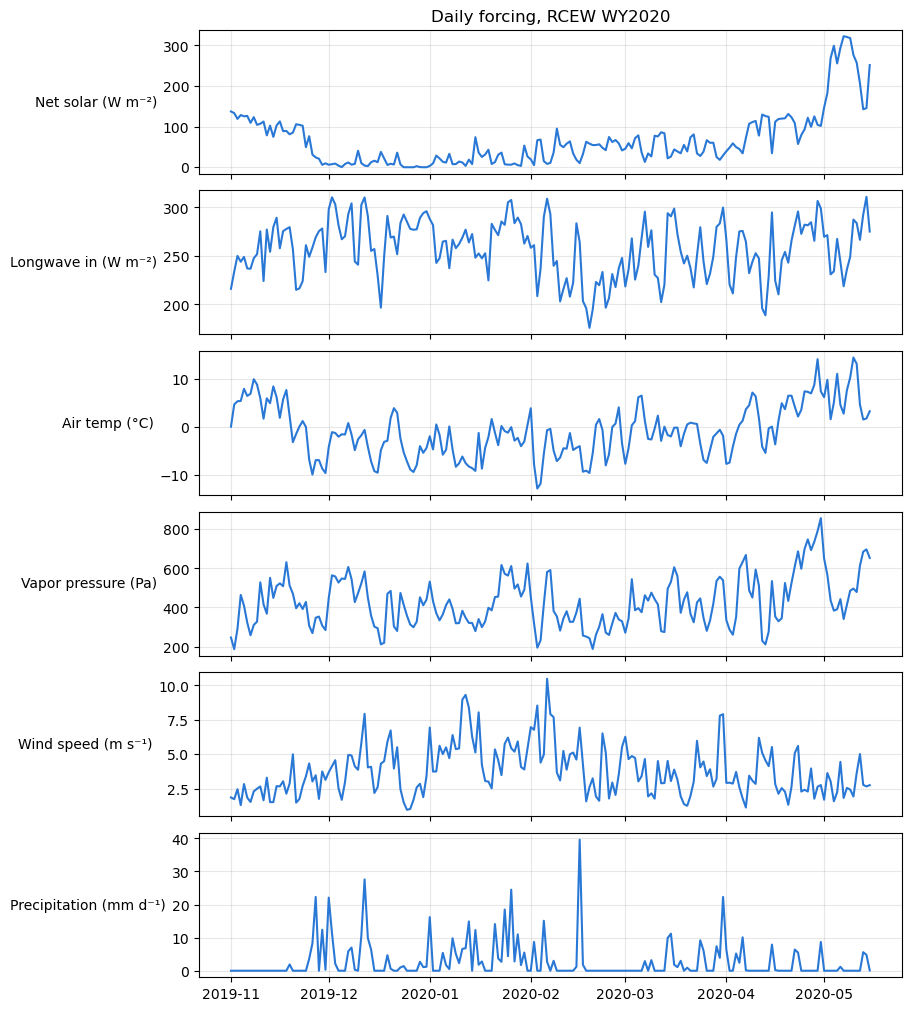

In [3]:
panels = {
    "net_solar_Wm-2": "Net solar (W m⁻²)",
    "downwelling_thermal_Wm-2": "Longwave in (W m⁻²)",
    "temp_air_degC": "Air temp (°C)",
    "vapor_pressure_Pa": "Vapor pressure (Pa)",
    "wind_speed_ms-1": "Wind speed (m s⁻¹)",
    "precip_mass_mm": "Precipitation (mm h⁻¹)",
}
fig, axes = plt.subplots(len(panels), 1, figsize=(9, 10), sharex=True, constrained_layout=True)
for ax, (col, label) in zip(axes, panels.items()):
    daily = forcing[col].resample("D").sum() if col == "precip_mass_mm" else forcing[col].resample("D").mean()
    ax.plot(daily.index, daily, color="#2a78d6", lw=1.5)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)
axes[-1].set_ylabel("Precipitation (mm d⁻¹)", rotation=0, ha="right", va="center")
axes[0].set_title("Daily forcing, RCEW WY2020");

## Configure the model

The configuration is a nested dictionary (or an equivalent YAML file, see
[`config.yaml`](https://github.com/iSnobal/pysnobal/blob/main/config/config.yaml)).
Only three groups are required:

- **`io`**: file paths, used by the command-line tool; unused when running from Python
- **`z`**: measurement heights above the ground (soil temperature: depth below it), in meters.
  These set the turbulent flux calculation
- **`params`**: site elevation and surface roughness length

Everything else (initial snowpack, layer thickness, time-step thresholds) falls back to
defaults when left out. Without an `init` group the run starts with no snow.

```{note}
The elevation below (2000 m) is the value used in the pysnobal test suite, not a surveyed site value.
```

In [4]:
elevation_input = 2000
config = {
    "io": {"forcing_path": "", "output_path": ""},
    "z": {"air_temp_m": 2.33, "soil_temp_m": 1.0, "wind_speed_m": 2.5},
    "params": {"elevation_m": elevation_input, "roughness_length_m": 0.001},
}

## Run Snobal

`run_snobal` returns a DataFrame with one row per forcing time step. We pass *copies* of the
forcing and config because pysnobal modifies its inputs in place (it renames columns,
converts temperatures to kelvin, and fills in defaults). This takes about a minute.

In [5]:
output = run_snobal(forcing.copy(), copy.deepcopy(config))
output.columns.tolist()

['net_radiation_Wm-2',
 'sensible_heat_flux_Wm-2',
 'latent_heat_flux_Wm-2',
 'advective_heat_flux_Wm-2',
 'ground_heat_flux_Wm-2',
 'inter_layer_heat_flux_Wm-2',
 'delta_snow_energy_Wm-2',
 'delta_active_layer_energy_Wm-2',
 'bulk_density_snow_kgm-3',
 'temp_snow_degC',
 'temp_active_layer_degC',
 'temp_lower_layer_degC',
 'thickness_snow_m',
 'thickness_active_layer_m',
 'thickness_lower_layer_m',
 'coldcontent_snow_Jm-2',
 'coldcontent_active_layer_Jm-2',
 'coldcontent_lower_layer_Jm-2',
 'specific_mass_snow_kgm-2',
 'specific_mass_active_layer_kgm-2',
 'specific_mass_lower_layer_kgm-2',
 'liquid_h2o_kgm-2',
 'h2o_sat_%',
 'evap_kgm-2',
 'snowmelt_kgm-2',
 'surface_Water_input_kg']

The output has energy fluxes (W m⁻²), layer temperatures, thicknesses, cold
content, and mass terms. `specific_mass_snow_kgm-2` is snow water equivalent (SWE):
1 kg m⁻² equals 1 mm of water.

## Compare with observations

Observed depths are in centimeters, so convert them to meters before plotting.

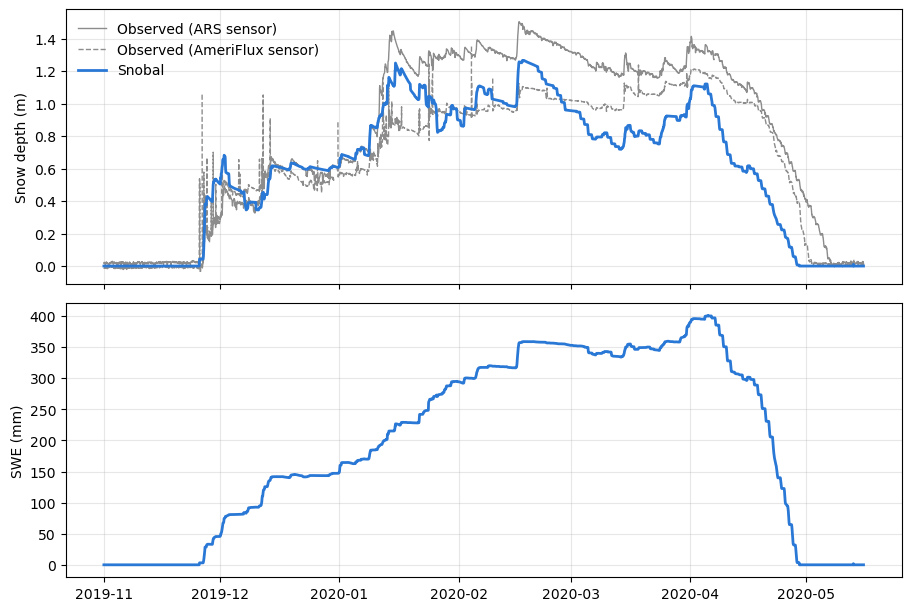

In [6]:
obs = forcing[["d_snow_ars", "d_snow_ameriflux"]] / 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)
ax1.plot(obs.index, obs["d_snow_ars"], color="#8c8c8c", lw=1, label="Observed (ARS sensor)")
ax1.plot(obs.index, obs["d_snow_ameriflux"], color="#8c8c8c", lw=1, ls="--", label="Observed (AmeriFlux sensor)")
ax1.plot(output.index, output["thickness_snow_m"], color="#2a78d6", lw=2, label="Snobal")
ax1.set_ylabel("Snow depth (m)")
ax1.legend(frameon=False)
ax1.grid(alpha=0.3)

ax2.plot(output.index, output["specific_mass_snow_kgm-2"], color="#2a78d6", lw=2)
ax2.set_ylabel("SWE (mm)")
ax2.grid(alpha=0.3);

A simple numeric check: the error in daily mean depth against the ARS sensor.

In [7]:
daily = pd.DataFrame({
    "model": output["thickness_snow_m"].resample("D").mean(),
    "obs": obs["d_snow_ars"].resample("D").mean(),
}).dropna()
err = daily["model"] - daily["obs"]
print(f"Bias: {err.mean():+.2f} m   RMSE: {(err**2).mean()**0.5:.2f} m   "
      f"Peak model: {daily['model'].max():.2f} m   Peak obs: {daily['obs'].max():.2f} m")

Bias: -0.20 m   RMSE: 0.28 m   Peak model: 1.26 m   Peak obs: 1.48 m


## Change a parameter

The roughness length $z_0$ controls how efficiently wind mixes heat and moisture
between the air and the snow surface. Increase it tenfold, from 1 mm to 1 cm, and rerun.

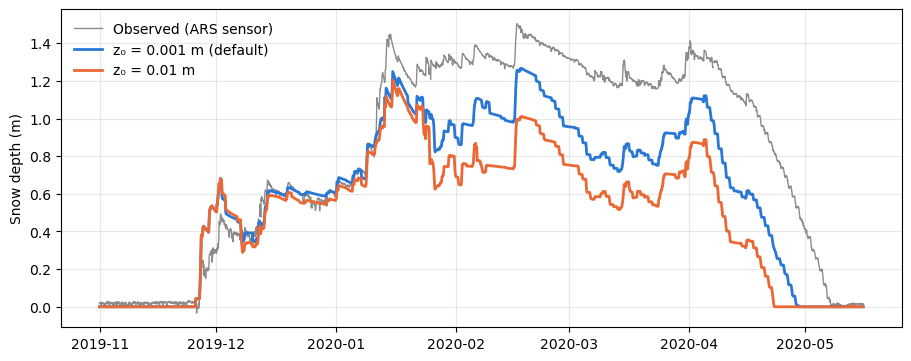

In [8]:
rough_config = copy.deepcopy(config)
rough_config["params"]["roughness_length_m"] = 0.01
rough = run_snobal(forcing.copy(), rough_config)

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
ax.plot(obs.index, obs["d_snow_ars"], color="#8c8c8c", lw=1, label="Observed (ARS sensor)")
ax.plot(output.index, output["thickness_snow_m"], color="#2a78d6", lw=2, label="z₀ = 0.001 m (default)")
ax.plot(rough.index, rough["thickness_snow_m"], color="#eb6834", lw=2, label="z₀ = 0.01 m")
ax.set_ylabel("Snow depth (m)")
ax.legend(frameon=False)
ax.grid(alpha=0.3);

Larger roughness strengthens the turbulent fluxes. Compare the season totals of
sensible and latent heat to see which way the change pushed the energy balance:

In [9]:
flux_cols = ["sensible_heat_flux_Wm-2", "latent_heat_flux_Wm-2"]
pd.DataFrame({
    "z₀ = 0.001 m (default)": output[flux_cols].mean(),
    "z₀ = 0.01 m": rough[flux_cols].mean(),
}).round(1).rename_axis("Season mean (W m⁻²)")

,z₀ = 0.001 m (default),z₀ = 0.01 m
Season mean (W m⁻²),,
sensible_heat_flux_Wm-2,11.5,20.9
latent_heat_flux_Wm-2,-8.1,-16.9


Try other parameters the same way: `params.elevation_m`, the measurement heights
in `z`, or `defaults.max_active_layer_thickness_m`.

## Next steps

- **Your own site:** build a forcing CSV with the columns above. The
  [data prep notebook](https://github.com/iSnobal/pysnobal/blob/main/notebooks/pysnobal_data_prep.ipynb)
  gives a template.
- **Command line:** the same run is `pysnobal -c config.yaml -o io.forcing_path=forcing.csv io.output_path=out.csv`.
- **Go spatial:** [Run the RME test basin](run_rme.md) runs iSnobal over a small watershed.